In [127]:
import pandas as pd

## Data Acquisition
https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008 

In [128]:
path = "../data/diabetic_data.csv"

df = pd.read_csv(path)

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [129]:
df.shape

(101766, 50)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [131]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

## Data Cleaning

- Clean target variable "readmitted"
- Convert target variable "readmitted" into boolean
- Missing Values
- Values with "?"

### Convert Target Variable

In [132]:
print(df["readmitted"].unique())

['NO' '>30' '<30']


In [133]:
# convert to string
df["readmitted"] = df["readmitted"].astype(str).str.strip()

In [134]:
# convert boolean
df["readmitted"] = df["readmitted"].map({
    "<30": 1,  # readmitted before 30 days 
    ">30": 0,  # readmitted after 30 days 
    "NO": 0
})

df["readmitted"]

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64

### Values with '?'

In [135]:
cols_with_question = df.columns[df.isin(['?']).any()].tolist()
print(cols_with_question)

['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']


Replace with nan

In [136]:
import numpy as np

df.replace('?', np.nan, inplace=True)

### Missing Values

In [137]:
print( (df.isna().sum() / len(df) ) * 100)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

Dropping columns over 80% missing values. The rest will be considered during transformation/pipelining. Dropping payer_code as its a insurance code

In [138]:
missing_pct = df.isna().mean() * 100

cols_to_drop = missing_pct[missing_pct > 80].index

df = df.drop(columns=cols_to_drop)
df.drop('payer_code', axis=1, inplace=True)

In [139]:
print( (df.isna().sum() / len(df) ) * 100)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide                  0.000000
chlorpropamide               0.000000
glimepiride                  0.000000
acetohexamide                0.000000
glipizide   

Drop payer_code as its a unique identifier for insurance.

In [14]:
df.drop('payer_code', axis=1, inplace=True)

### Convert Categorical Data

In [15]:
df_cat = df.select_dtypes(include='object')
df_cat.head(5)

,race,gender,age,medical_specialty,diag_1,diag_2,diag_3,metformin,repaglinide,nateglinide,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),Pediatrics-Endocrinology,250.83,NaN,NaN,No,No,No,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,276,250.01,255,No,No,No,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,648,250,V27,No,No,No,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,8,250.43,403,No,No,No,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,197,157,250,No,No,No,...,No,No,Steady,No,No,No,No,No,Ch,Yes


## Correlations

In [16]:
corr = df.corr(numeric_only=True)["readmitted"].sort_values(ascending=False).head(10)
print(corr)

readmitted                  1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
patient_nbr                 0.007893
Name: readmitted, dtype: float64


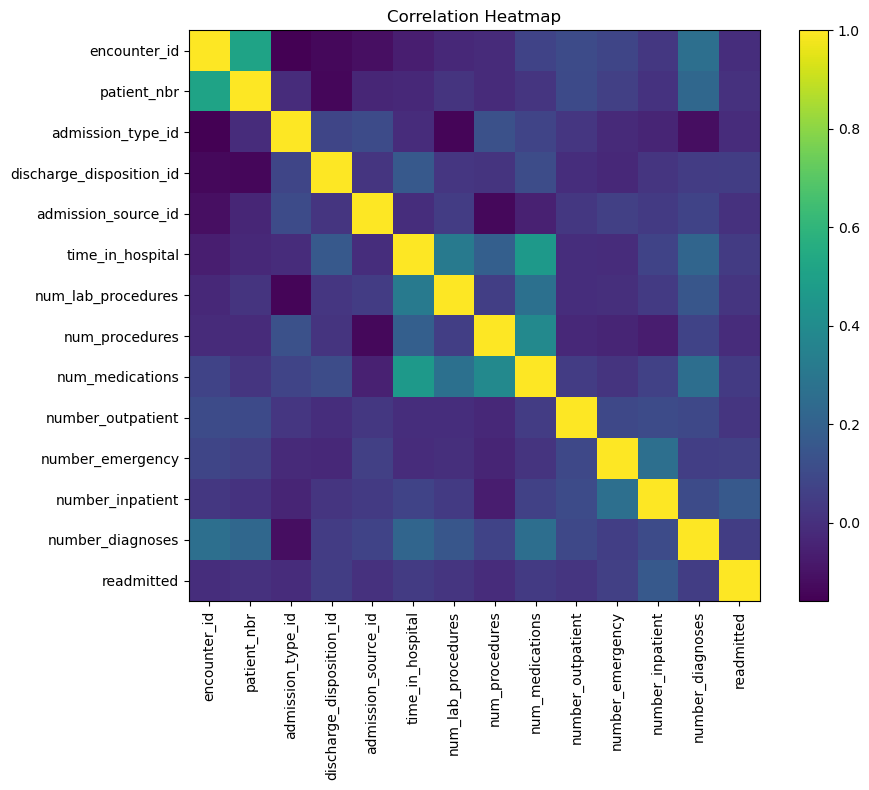

In [17]:
import matplotlib.pyplot as plt

# select numeric columns
numeric_df = df.select_dtypes(include="number")

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Distributions

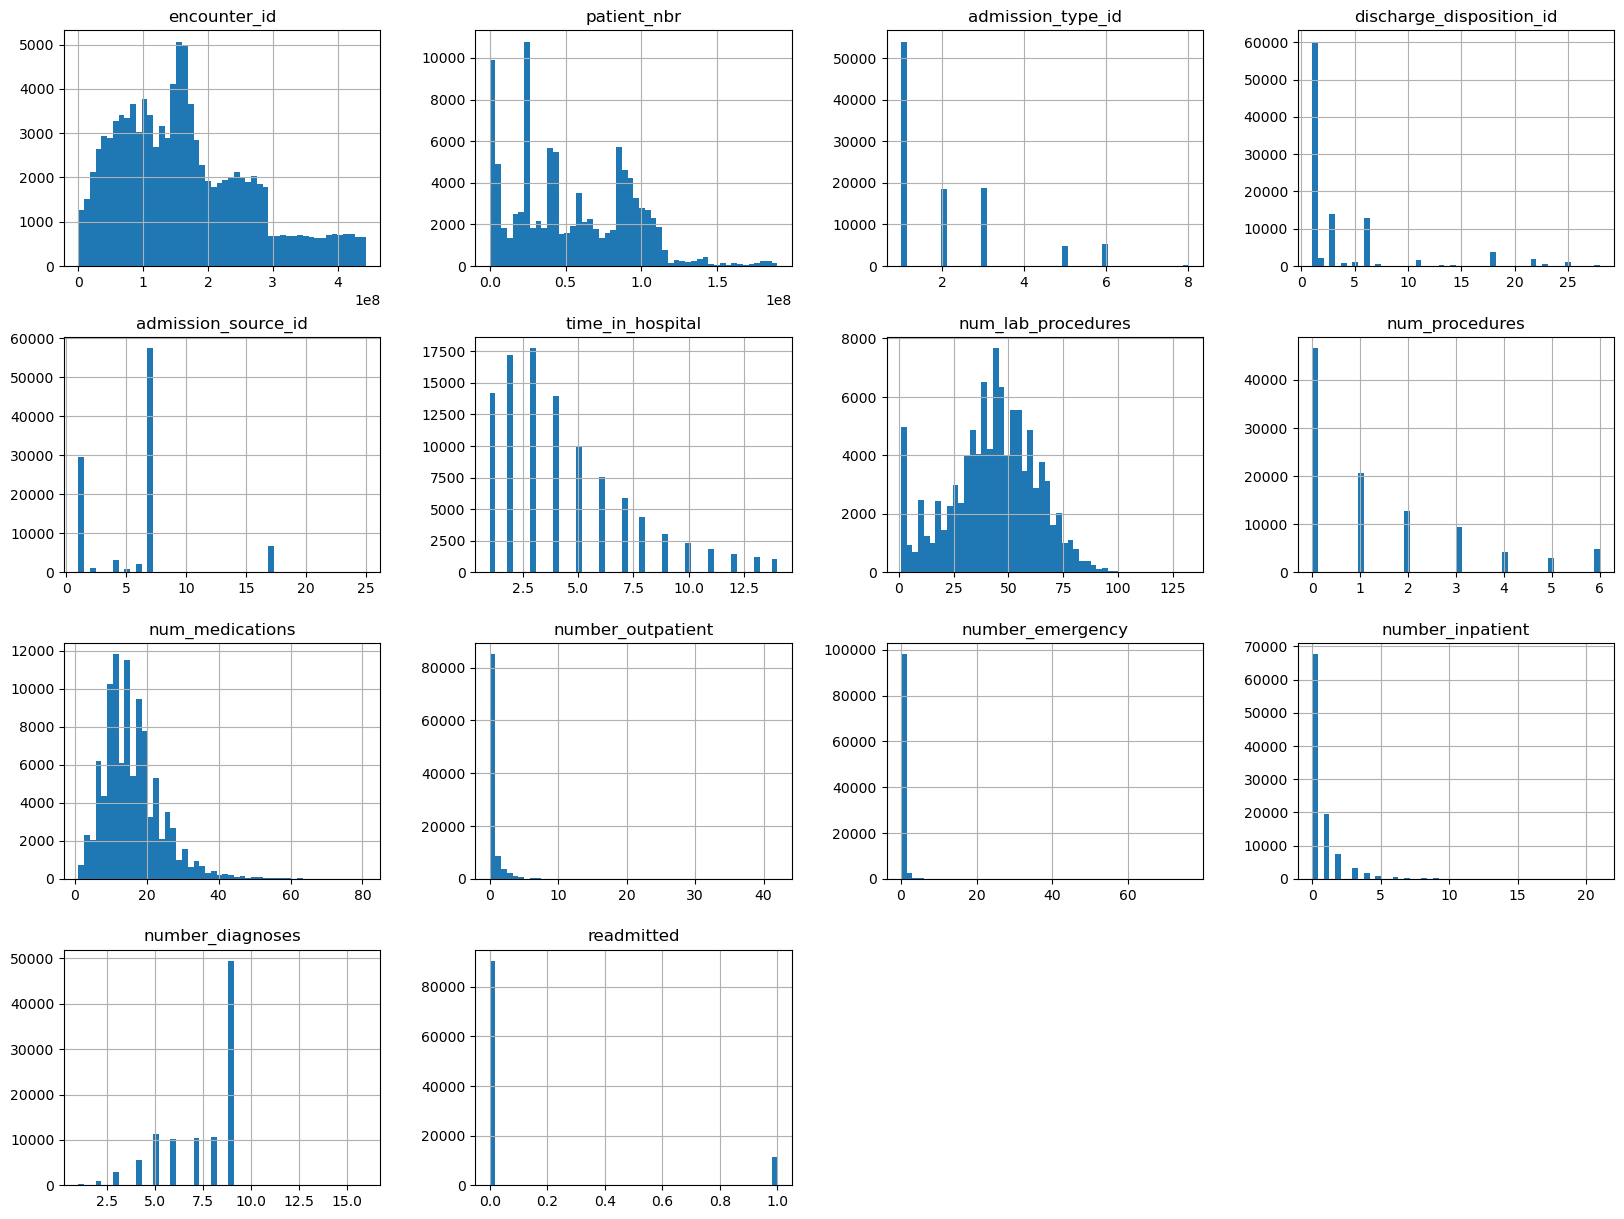

In [18]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

## EDA

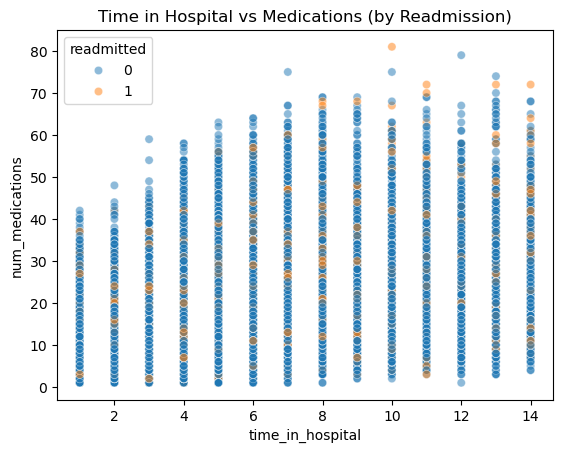

In [19]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='time_in_hospital',
    y='num_medications',
    hue='readmitted',
    alpha=0.5
)

plt.title('Time in Hospital vs Medications (by Readmission)')
plt.show()

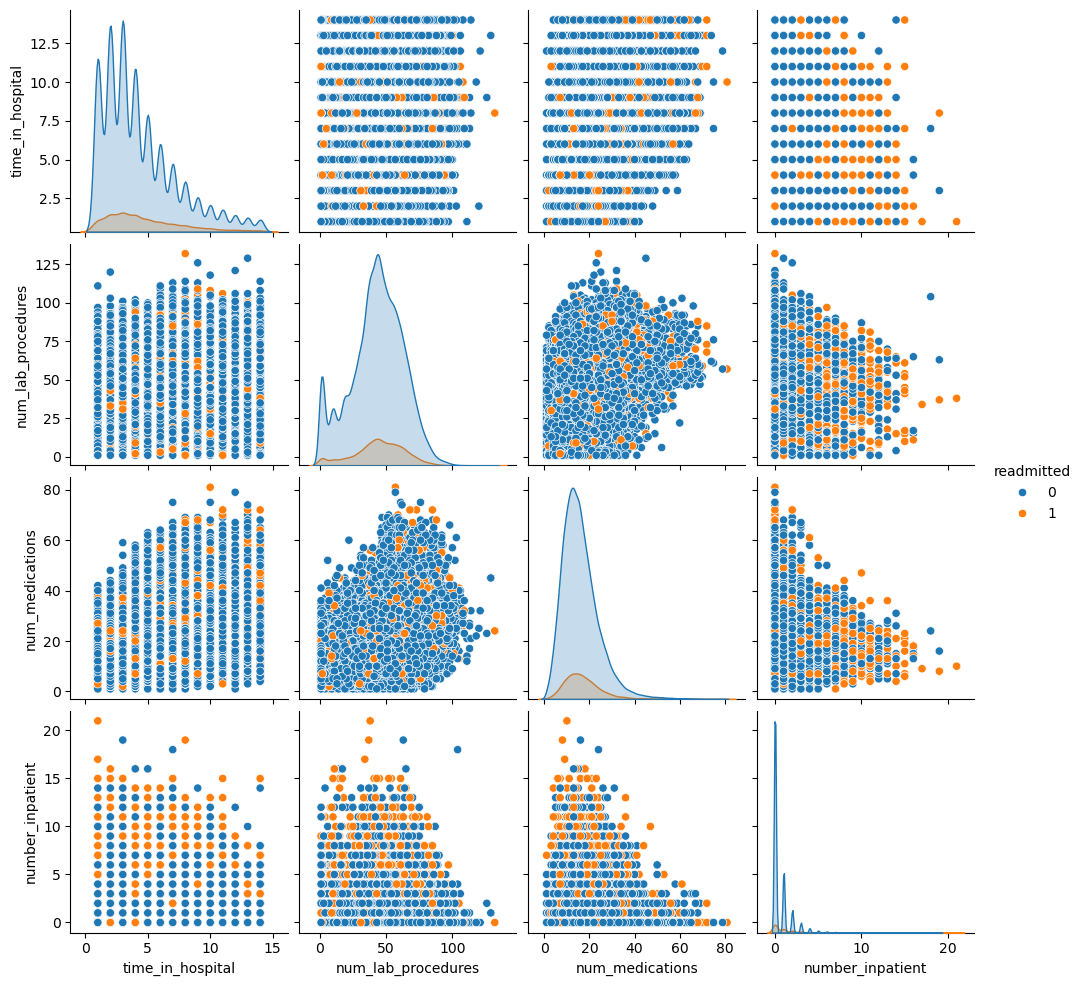

In [20]:
cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient']

sns.pairplot(df[cols + ['readmitted']], hue='readmitted')

Time in hospital vs readmitted

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

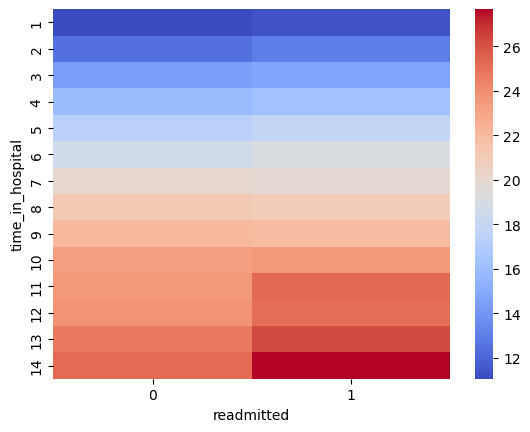

In [21]:
pivot = df.pivot_table(
    values='num_medications',
    index='time_in_hospital',
    columns='readmitted',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm')

In [147]:
df_corr = df.copy()

In [23]:
df_corr.shape

(101766, 46)

In [27]:
df_corr["severity"] = df["time_in_hospital"] * df["num_medications"]

In [28]:
df_corr["severity"] = df["time_in_hospital"] * (df["number_diagnoses"] + 1)

In [29]:
df_corr['total_visits'] = (
    df_corr['number_inpatient'] +
    df_corr['number_outpatient'] +
    df_corr['number_emergency']
)

In [30]:
df_corr['com'] = df["number_diagnoses"] + df["num_medications"] + df["num_medications"]

In [31]:
corr = df_corr.corr(numeric_only=True)["readmitted"].sort_values(ascending=False)
print(corr)

readmitted                  1.000000
number_inpatient            0.165147
total_visits                0.126114
number_emergency            0.060747
discharge_disposition_id    0.050560
severity                    0.050252
number_diagnoses            0.049524
severity3                   0.045384
time_in_hospital            0.044199
com                         0.042722
severity                    0.041994
Name: readmitted, dtype: float64


## Saving

In [32]:
df.to_csv("../data/df_diabetic.csv", index=False)